In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid
from datetime import datetime

In [2]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeCustom' in i:
            new_name = i.replace('timeCustom_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

def n_to_xr_idx(n):
    """Convert from 1-indexed mesh ID to 0-indexed Python index"""
    return n-1

def xr_to_n_idx(xr):
    """Convert from 0-indexed Python index to 1-indexed mesh ID"""
    return xr+1

def remove_nans(xr_raw):
    xr = np.delete(np.unique(xr_raw), np.unique(xr_raw)==-1)
    return xr

# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'extend',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     to = 'outer',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'],
                                                      'Z',
                                                      padding = 'extend').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [4]:
sim_res = '5km'
filepath = f'/pscratch/sd/k/kuyeda/WMT_DVD/bichan/{sim_res}/'
# filepath = f'/pub/kailau/WMT_DVD/bichan/{sim_res}/'

suffix = '_30days' # '_with_vertAdv' # '_12day_HF_no_adv_no_ALE_no_diff' # '_with_vertAdv' #'_12day_HF_no_adv_no_ALE' #_12day_HF_no_adv_no_ALE_no_diff' # '_with_vertAdv' # '_12day_HF_no_adv' # '_12day_HF' '_with_vertAdv '_no_adv'
# averaged values (time = 10*n + 5)
avg_ds_output = xr.open_dataset(filepath + f'/analysis_members/mpaso.hist.am.timeSeriesStatsCustomAvg_{sim_res}_channel.0001-01-01.nc' + suffix,decode_times=False)

# rename variables to remove the "timeCustom_avg" and "activeTracer__" prefixes
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# snapshots at every timestep (dt = 10 mins)
ss_ds_output = xr.open_dataset(filepath + f'{sim_res}_channel_output.nc' + suffix,decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
ss_ds_output['salinity'] = ss_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', padding = 'extend')

mesh = xr.open_dataset(filepath + f'{sim_res}_channel_init.nc')
mesh = mesh.assign_coords({'xr_idx': n_to_xr_idx(mesh.indexToCellID)})
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

time_idx = 500

(300000.0, 325553.3830393002)

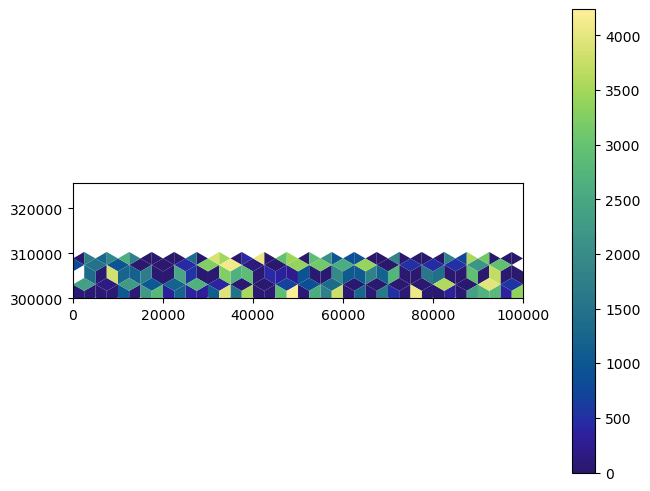

In [5]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =1, constrained_layout=True)
a = mosaic.polypcolor(ax, descriptor, mesh.nEdges, cmap='cmo.haline')
ax.set_aspect(1.0)
fig.colorbar(a, ax=ax)
ax.set_ylim(300000,None)

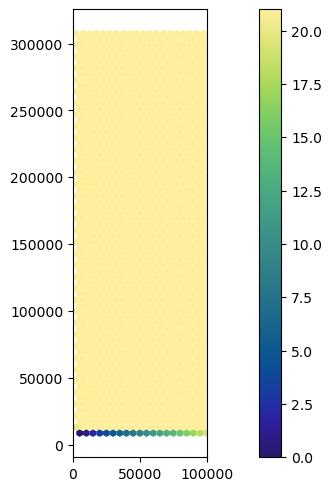

In [6]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =1, constrained_layout=True)
a = mosaic.polypcolor(ax, descriptor, mesh.nCells, cmap='cmo.haline', vmin=0, vmax = 21)
ax.set_aspect(1.0)
fig.colorbar(a, ax=ax)

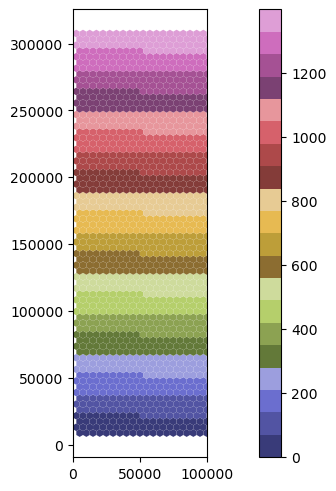

In [7]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =1, constrained_layout=True)
a = mosaic.polypcolor(ax, descriptor, mesh.nCells, cmap='tab20b')
ax.set_aspect(1.0)
fig.colorbar(a, ax=ax)

In [8]:
# set up the same grid as when you calculate G_chi_num
# eventually, this should probably be written as a helper function to be consistent across all budget calculation functions
# set target coordinate bins
ds_output = avg_ds_output
target_coord_spacing = 1

lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)

d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array

# create a grid to transform chi from nVertLevels to salinity coords
grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
            padding = 'extend',
            autoparse_metadata = False)


In [9]:
# area-weight all cells to create a new datavariable
avg_ds_output['chiSpurSaltBR08_dA'] = avg_ds_output.chiSpurSaltBR08 * mesh.areaCell

# remap avg_ds_output into salinity space
# transform
chiSpurSaltBR08_dA_salinity = grid.transform(avg_ds_output['chiSpurSaltBR08_dA'], # currently sitting on cell centers
                                 'Z',
                                 target_coords_P1, # conservative remap requires specifying target edge coords
                                 method = 'conservative', # conservative remap since we've already weighted chi with area
                                 target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords

chiSpurSaltBR08_dA_salinity = chiSpurSaltBR08_dA_salinity.to_dataset(name = 'chiSpurSaltBR08_dA_salinity').rename({'salinity_P1' : 'salinity'})
    
# add back salinity_P1 coords
# chiSpurSaltBR08_dA_salinity['salinity_P1'] = target_coords_P1
chiSpurSaltBR08_dA_salinity['chiSpurSaltBR08_dA_salinity'] = chiSpurSaltBR08_dA_salinity.chiSpurSaltBR08_dA_salinity.transpose('nCells','Time','salinity')

In [10]:
def chi_group_avg(idx, mesh, chiSpurSaltBR08_dA_salinity):
    n_cellsOnCenterCell = mesh.isel(nCells = idx).cellsOnCell
    xr_cellsOnCenterCell_raw = n_to_xr_idx(n_cellsOnCenterCell)
    xr_cellsOnCenterCell = np.int32(xr_cellsOnCenterCell_raw.where(xr_cellsOnCenterCell_raw > 0).dropna(dim='maxEdges'))
    xr_cellsInGroup = np.append(xr_cellsOnCenterCell, idx)
    n_cellsInGroup = xr_to_n_idx(xr_cellsInGroup)
    
    # select the group of cells from chiSpurSaltBR08_da_salinity that you will average over
    group = chiSpurSaltBR08_dA_salinity.isel(nCells = xr_cellsInGroup)
    
    # take the average of the group over nCells (an average has been calculated at every salinity surface at every time)
    group_avg = group.chiSpurSaltBR08_dA_salinity.mean(dim='nCells', skipna=True)
    
    # reassign the groupCell values to now be the group_avg value that was calculated at the salinity surface the groupCell occupied
    group_avg_assigned_raw = group_avg.broadcast_like(group)
    
    # NaNs (i.e., cells not on a salinity surface but in the group) were assigned a value 
    # use the original grouping to create a mask
    group_nan_mask = group.notnull()
    
    # apply this mask to the group_avg_assigned_raw
    group_avg_assigned = group_avg_assigned_raw.where(group_nan_mask)

    return group_avg_assigned, xr_cellsInGroup

In [11]:
# collect all cells surrounding a center + the center cell
# then average over all those cells
averaged_da = (chiSpurSaltBR08_dA_salinity.chiSpurSaltBR08_dA_salinity /chiSpurSaltBR08_dA_salinity.chiSpurSaltBR08_dA_salinity).copy()

# start an array to keep track of which cells have already been used
used_cells = np.array([])
idx = 0

while len(used_cells) < len(mesh.nCells):
    group_avg_assigned, xr_cellsInGroup = chi_group_avg(idx, mesh, chiSpurSaltBR08_dA_salinity)
    
    # update averaged_da dataArray
    averaged_da.loc[{'nCells' : xr_cellsInGroup}] = group_avg_assigned.chiSpurSaltBR08_dA_salinity
    
    # update used_cells
    used_cells = np.append(used_cells, xr_cellsInGroup)
    
    # find next cell to move to. Because bichan has some spatial coherence (e.g., L to R, bottom to top), we can average in a similar direction
    # get all the potential cellsOngroupCells 
    n_cellsOnGroupCells = mesh.isel(nCells = xr_cellsInGroup).cellsOnCell
    xr_cellsOnGroupCells_raw = n_to_xr_idx(n_cellsOnGroupCells)
    xr_cellsOnGroupCells = remove_nans(xr_cellsOnGroupCells_raw)
    
    # then get all the cells on the cellsOnGroupCells
    n_potential_nextCenterCells = np.unique(mesh.isel(nCells = xr_cellsOnGroupCells).cellsOnCell)
    xr_potential_nextCenterCells_raw = n_to_xr_idx(n_potential_nextCenterCells)
    xr_potential_nextCenterCells = remove_nans(xr_potential_nextCenterCells_raw)
    
    # of these cellsOnGroupCells, the next center cell canNOT have already been part of an average
    xr_unused_potential_nextCenterCells = np.int32(np.setxor1d(used_cells, xr_potential_nextCenterCells))
    
    # and the cells in the next potential group canNOT have already been part of an average
    # get teh cells that could be part of the next gropu (cellsOn_potential_nextCenterCells)
    n_cellsOn_unused_potential_nextCenterCells = mesh.isel(nCells = xr_unused_potential_nextCenterCells).cellsOnCell
    xr_cellsOn_unused_potential_nextCenterCells_raw = n_to_xr_idx(n_cellsOn_unused_potential_nextCenterCells)
    xr_cellsOn_unused_potential_nextCenterCells = xr_cellsOn_unused_potential_nextCenterCells_raw.where(xr_cellsOn_unused_potential_nextCenterCells_raw > 0)
    
    # iterate over these potential next groups
    # if they contain a cell that has already been used for an average, ignore it.
    
    for i in range(0, len(xr_cellsOn_unused_potential_nextCenterCells.nCells)):
        cellsOnPotentialCenters_intersect_used = np.intersect1d(xr_cellsOn_unused_potential_nextCenterCells.isel(nCells = i), used_cells)
        
        if len(cellsOnPotentialCenters_intersect_used) == 0:
            next_center = xr_cellsOn_unused_potential_nextCenterCells.isel(nCells = i).xr_idx.values
            break
    
    idx = next_center


In [12]:
# since the chi_num term has already been remapped to salinity coordinates, we calculate G_num from a different place than the usual function
# this is already weighted by cell area, so integrating over volume just requires multiplying by the target_lambda_spacing
chi_dA_num_salinity = averaged_da
chi_dA_num_salinity = chi_dA_num_salinity.to_dataset(name = 'chi_dA_num_salinity').assign_coords({'salinity_P1' : target_coords_P1})

target_coord_spacing = 1
mixing = chi_dA_num_salinity * target_coord_spacing
ds_output = avg_ds_output

# create a grid for salinity coordinates
salinity_grid = Grid(chi_dA_num_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                     padding = 'extend',
                     autoparse_metadata = False)

# integrate mixing by doing a reverse cumsum over lambda values
cumulative_mixing = salinity_grid.cumsum(chi_dA_num_salinity.chi_dA_num_salinity,
                                         'Z',
                                         to = 'outer',
                                         reverse='true').to_dataset(name = 'cumulative_chi_num_mixing')

# add back salinity_P1 coords
cumulative_mixing['salinity'] = target_coords

# interpolate back onto salinity coords
cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing.cumulative_chi_num_mixing,
                                                  'Z',
                                                  padding = 'extend').transpose('salinity', 'nCells', 'Time')

# calculate the first derivative (mixing per salinity class) 
# taking a difference will put values back onto salinity_P1 coords
mixingPerSalinityClass = []

# take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
# requires coords to be ordered as (salinity, nCells, Time)

for i in range(0,len(target_coords)-1):
    d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
    d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
    mixingPerSalinityClass.append(d_mixing_d_lambda)

# convert mixingPerSalinityClass to dataarray
mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')

# take the second derivative (from salinity_P1 coords back to salinity coords)
# again, by taking the differrence, you will lose the first and last entries of the salinity coords
# this derivative calculates the convergence of the mixing flux

G_chi_mix = []

for i in range(0,len(target_coords)-2):
    d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
    conv_mixingFlux = d_mixingFlux / d_lambda
    G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2

# convert G_chi_mix to dataset
G_chi_mix_ds_coarsened = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_num')

# add back the salinity_P1 coordinates
G_chi_mix_ds_coarsened = G_chi_mix_ds_coarsened.assign_coords({'salinity_P1' : salinity_P1_trimmed})

In [13]:
G_chi_mix_ds = calculate_G_chi_mix('chiSpurSaltBR08', 1026, mesh, avg_ds_output, 1)

Calculating G_chi_num


Text(0.5, 0.98, 'Time-averaged WMT budget for $\\mathcal{G}_\\chi^{\\text{(num)}}$\n5km, $\\Delta \\lambda=1$')

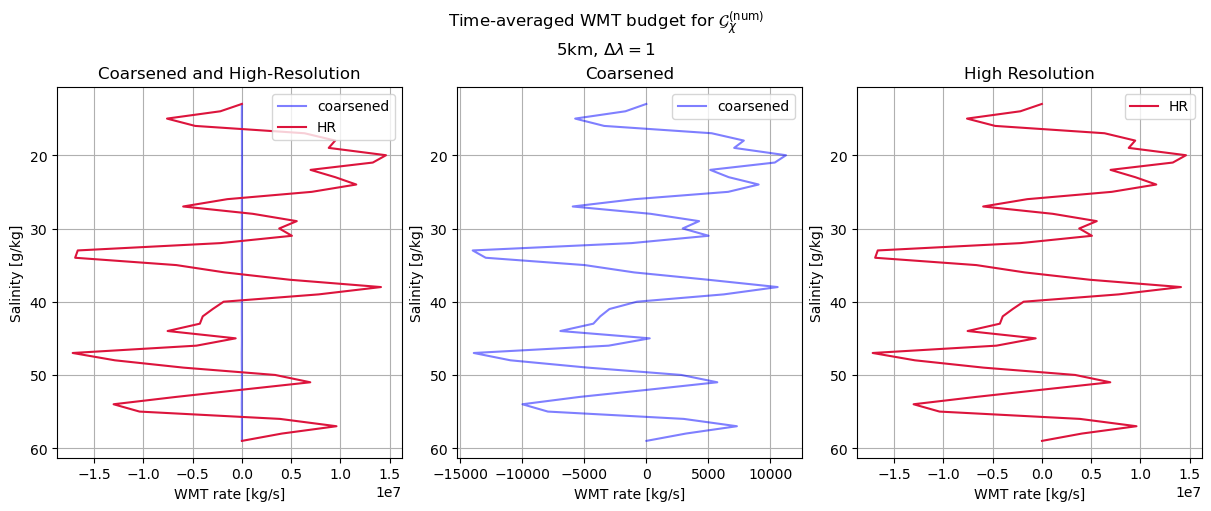

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=3, constrained_layout=True, figsize=(12,5))
G_chi_mix_ds_coarsened.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[0], y='salinity', color='blue', alpha = 0.5, label = 'coarsened')
G_chi_mix_ds.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[0], y='salinity', color = 'crimson', label = 'HR')

G_chi_mix_ds_coarsened.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[1], y='salinity', color='blue', alpha = 0.5, label = 'coarsened')
G_chi_mix_ds.G_chi_num.sum('nCells').mean(dim='Time').plot(ax = ax[2], y='salinity', color = 'crimson', label = 'HR')

for i in range(0,3):
    ax[i].grid()
    ax[i].legend()
    ax[i].invert_yaxis()
    ax[i].set_xlabel('WMT rate [kg/s]')
    ax[i].set_ylabel('Salinity [g/kg]')
    
ax[0].set_title('Coarsened and High-Resolution')
ax[1].set_title('Coarsened')
ax[2].set_title('High Resolution')
fig.suptitle(r'Time-averaged WMT budget for $\mathcal{G}_\chi^{\text{(num)}}$' + '\n' + r'5km, $\Delta \lambda=1$')



In [15]:
len(used_cells)

1400

In [16]:
len(np.unique(used_cells))

1145

In [17]:
chi_num_salinity = grid.transform((avg_ds_output.chiSpurSaltBR08 * mesh.areaCell),
                                   'Z',
                                   target_coords,
                                   method = 'linear',
                                   target_data = avg_ds_output.salinity)
chi_num_salinity = chi_num_salinity.to_dataset(name = 'chi_num_salinity')

Text(0.5, 0.98, 'Coarsened vs HR $\\chi^{\\text{(num)}}$\nsalinity = 18.96 g/kg')

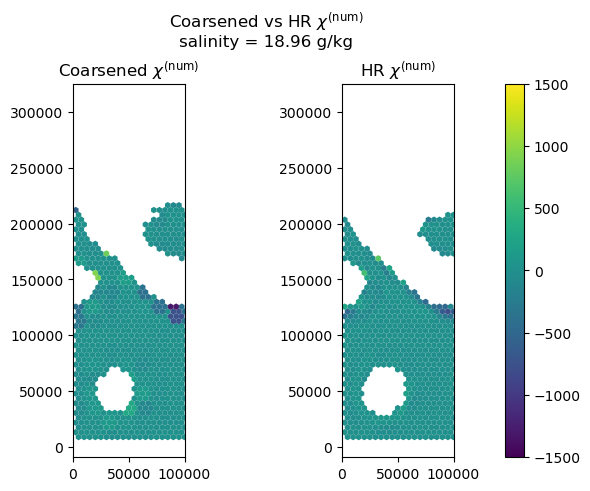

In [18]:
# visualize the mesh
fig,ax = plt.subplots(nrows=1, ncols =2, constrained_layout=True)
salinity_idx = 7
vmin_val = -1500
vmax_val = 1500

a = mosaic.polypcolor(ax[0], descriptor, averaged_da.isel(Time=-1,salinity= salinity_idx),vmin= vmin_val, vmax = vmax_val)
b = mosaic.polypcolor(ax[1], descriptor, chi_num_salinity.chi_num_salinity.isel(Time=-1, salinity = salinity_idx),vmin= vmin_val, vmax = vmax_val)
ax[0].set_aspect(1.0)
ax[1].set_aspect(1.0)

ax[0].set_title(r'Coarsened $\chi^{\text{(num)}}$')
ax[1].set_title(r'HR $\chi^{\text{(num)}}$')

fig.colorbar(a, ax=ax)
fig.suptitle(r'Coarsened vs HR $\chi^{\text{(num)}}$' + '\n' + f'salinity = {np.round(averaged_da.salinity[salinity_idx].values, 2)} g/kg')

In [19]:
averaged_da.salinity[0]

<xarray.DataArray 'salinity' ()> Size: 8B
array(11.96256044)
Coordinates:
    salinity  float64 8B 11.96